---
title: "モートン符号についての考察"
description: "モートン符号の基本を簡単に"
date: 2025-07-06T09:00:00+09:00
categories:
  - computerscience
  - mortoncode
draft: false
---

## モートン符号の範囲

ここでは表示の都合上，2 次元で各軸が 4bits の 8bits を対象とする．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0 \\
\hline
y_3 & x_3 & y_2 & x_2 & y_1 & x_1 & y_0 & x_0 \\
\end{array}
$$

In [1]:
import numpy as np


def interleave_bits(x):
    x = np.asarray(x, dtype=np.uint32)
    x = (x | (x << 2)) & 0x00000033
    x = (x | (x << 1)) & 0x00000055
    return x


def deinterleave_bits(x):
    x = np.asarray(x, dtype=np.uint32)
    x = x & 0x00000055
    x = (x | (x >> 1)) & 0x00000033
    x = (x | (x >> 2)) & 0x0000000F
    return x


def encode_morton(v):
    v = np.asarray(v)
    v = interleave_bits(v)
    x = np.take(v, 0, axis=-1)
    y = np.take(v, 1, axis=-1)
    return (y << 1) | x


def decode_morton(code):
    code = np.asarray(code)
    x = deinterleave_bits(code)
    y = deinterleave_bits(code >> 1)
    return np.stack([x, y], axis=-1)

## Z-order curve

Z-order curve の由来である Z を可視化する．ただし，原点は左下とする．

**※ `np.argsort` を利用しているが，本来は基数ソートを用いる．例えば 30bits のモートン符号なら 6bits 単位で基数ソートをするなど．**

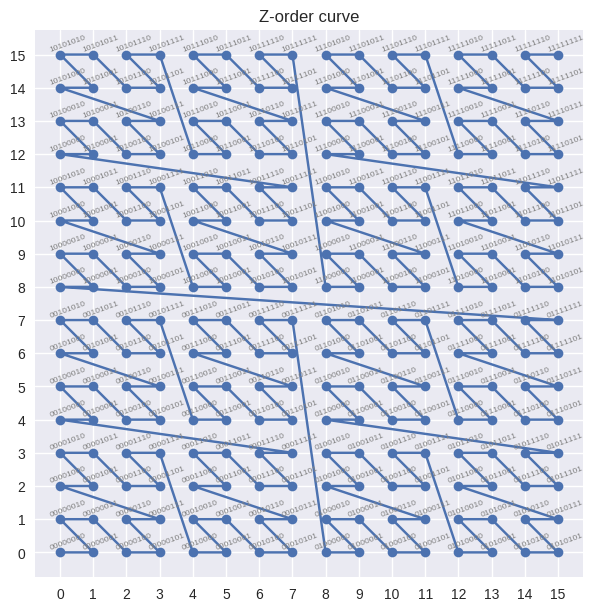

In [2]:
import math
import matplotlib.pyplot as plt


# print(plt.style.available)
plt.style.use("seaborn-v0_8")


def plot_z_order_curve(ax):
    xx, yy = np.meshgrid(np.arange(16), np.arange(16), indexing="xy")
    points = np.stack([xx.ravel(), yy.ravel()], axis=1)
    codes = encode_morton(points)
    inds = np.argsort(codes, kind="stable")  # Radix sort is preferable here, but not used for simplicity.
    points[:] = points[inds]
    codes[:] = codes[inds]

    ax.plot(points[:, 0], points[:, 1], "-o")

    for (x, y), code in zip(points, codes):
        ax.text(x - 0.35, y + 0.1, f"{code:08b}", fontsize=6, color="gray", rotation=20)


fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

plot_z_order_curve(ax)

# Styling and layout
ax.set_title("Z-order curve")
ax.set_xticks(np.arange(16))
ax.set_yticks(np.arange(16))
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.show()

## 任意の点群への応用

1. 点群を囲む軸平行境界ボックスを求める
2. 各点の座標から境界ボックスの最小値を引いて相対座標を求める
3. 相対座標を境界ボックスで正規化する
4. 正規化された総体座標をスケールする

In [3]:
def sample_circle_boundary(u, *, radius=1.0):
    theta = 2.0 * np.pi * u
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return np.stack((x, y), axis=-1)


def sample_circle_interior(u0, u1, *, radius=1.0):
    radius *= np.sqrt(u0)
    theta = 2.0 * np.pi * u1
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return np.stack((x, y), axis=-1)


def generate_points(size, radius, *, center=(0.0, 0.0)):
    u0 = np.random.uniform(size=size)
    u1 = np.random.uniform(size=size)
    # points = sample_circle_boundary(u0, radius=radius)
    points = sample_circle_interior(u0, u1, radius=radius)
    points += np.asarray(center)
    return points

In [4]:
np.random.seed(1)

points = generate_points(100, 7.5, center=(7.5, 7.5))

lower = np.min(points, axis=0)
upper = np.max(points, axis=0)
extent = upper - lower

normalzied = (points - lower) / extent
scaled = np.minimum(15, np.floor(normalzied * 16))

codes = encode_morton(scaled)
inds = np.argsort(codes, kind="stable")  # Radix sort is preferable here, but not used for simplicity.

points[:] = points[inds]
codes[:] = codes[inds]

## 範囲検索

モートン符号の任意の bit(s) に注目することで，領域に属する点群を検索することができる．いくつかの例を示す．

In [5]:
def plot_points(points, ax, **kwargs):
    merged = dict(color="black", markersize=7, alpha=0.5)
    merged.update(kwargs)
    ax.plot(points[:, 0], points[:, 1], "o", **merged)


def plot_bounds(lower, upper, ax, **kwargs):
    merged = dict(fill=False, edgecolor="black", linestyle="--", linewidth=1, alpha=0.5)
    merged.update(kwargs)
    extent = upper - lower
    rect = plt.Rectangle(lower, extent[0], extent[1], **merged)
    ax.add_patch(rect)
    ax.update_datalim(rect.get_path().vertices)
    ax.autoscale_view()


def plot_region(points, codes, mask, value, ax):
    plot_points(points, ax, markersize=3)

    lower, upper = np.min(points, axis=0), np.max(points, axis=0)
    plot_bounds(lower, upper, ax)

    mask = (codes & mask) == value
    matched_points = points[mask]
    if matched_points.shape[0] > 0:
        plot_points(matched_points, ax, color="crimson", markersize=6, markerfacecolor="none", markeredgewidth=1)


def generate_regions(mask, width=8):
    if mask == 0:
        return []

    # (~mask + 1) is used instead of -mask to avoid overflow warnings with np.uint32 (equivalent in two's complement).
    # pos = int(mask & -mask).bit_length() - 1
    pos = int(mask & (~mask + 1)).bit_length() - 1

    length = mask >> pos
    n_bits = int(length).bit_length()
    n_values = length + 1

    results = []
    for i in range(n_values):
        val = np.uint32(i << pos)
        val_str = f"{val:0{width}b}"
        label = val_str[: width - pos] + "x" * pos
        results.append((val, label))

    return results


def plot_regeions(points, codes, mask, cols=None):
    regions = generate_regions(mask)
    num_regions = len(regions)

    if cols is None:
        cols = math.ceil(math.sqrt(num_regions))
    else:
        cols = min(cols, num_regions)

    rows = math.ceil(num_regions / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows), constrained_layout=True)
    axes = np.array(axes).ravel()
    for i, region in enumerate(regions):
        ax = axes[i]
        plot_region(points, codes, mask, region[0], ax)
        ax.set_title(region[1])
        ax.set_xlim(-1, 16)
        ax.set_ylim(-1, 16)
        ax.set_xticks(np.arange(16))
        ax.set_yticks(np.arange(16))
        ax.tick_params(axis="both", labelsize=8)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True)

    plt.show()

### 上位 1bit 目の領域

全体を上下 1/2 に分割．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
y_3 & - & - & - & - & - & - & -\\
\end{array}
$$

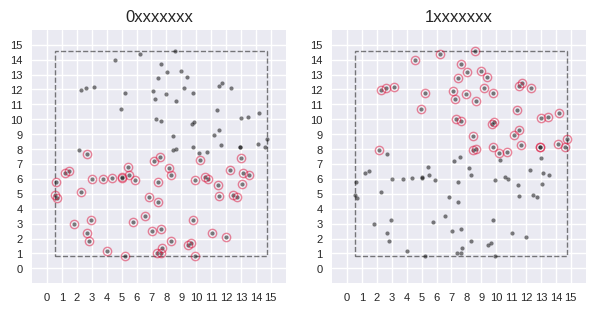

In [6]:
plot_regeions(points, codes, np.uint32(0b10000000), 4)

### 上位 2bit 目の領域

全体を左右 1/2 に分割．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
- & x_3 & - & - & - & - & - & -\\
\end{array}
$$

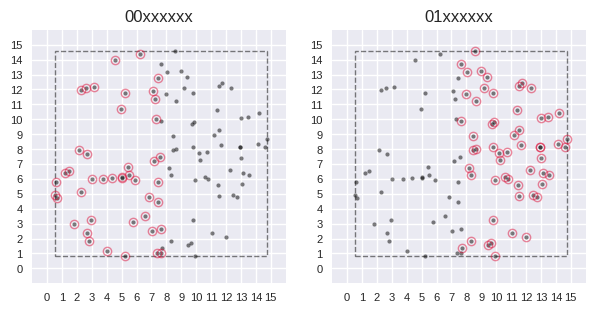

In [7]:
plot_regeions(points, codes, np.uint32(0b01000000), 4)

### 上位 3bit 目の領域

全体を上下 1/2 に分割し，各々を上下 1/2 に分割．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
- & - & y_2 & - & - & - & - & -\\
\end{array}
$$

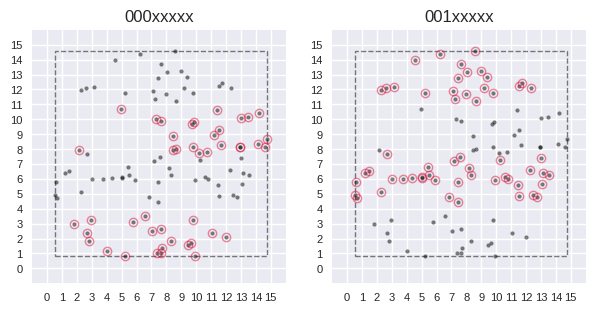

In [8]:
plot_regeions(points, codes, np.uint32(0b00100000), 4)

### 上位 4bit 目の領域

全体を左右 1/2 に分割し，各々を左右 1/2 に分割．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
- & - & - & x_2 & - & - & - & -\\
\end{array}
$$

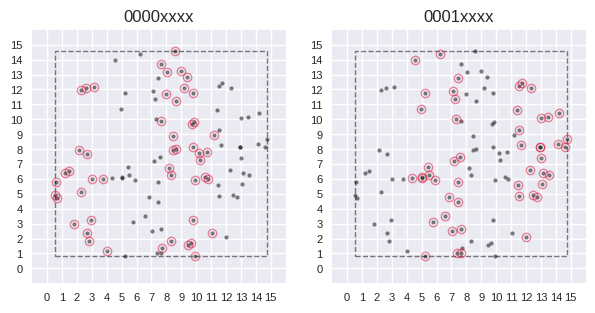

In [9]:
plot_regeions(points, codes, np.uint32(0b00010000), 4)

### 上位 2bits の領域

全体を 1/4 で分けた領域．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
y_3 & x_3 & - & - & - & - & - & -\\
\end{array}
$$

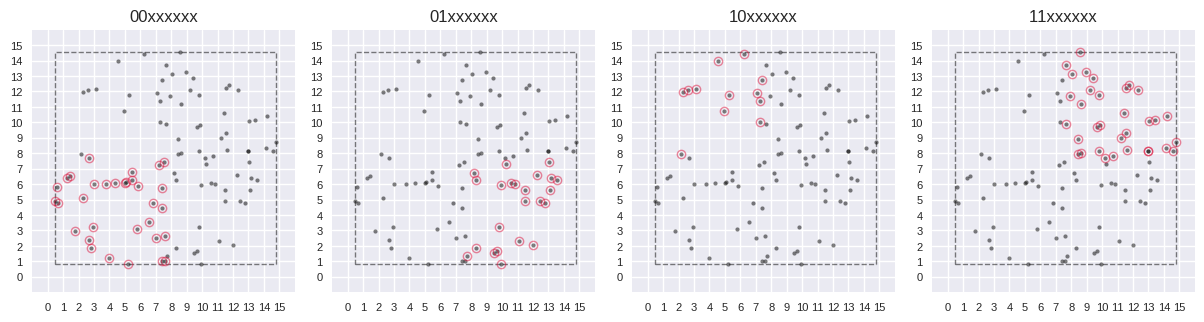

In [10]:
plot_regeions(points, codes, np.uint32(0b11000000), 4)

### 上位 3bits の領域

全体を 1/8 で分けた領域．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
y_3 & x_3 & y_2 & - & - & - & - & -\\
\end{array}
$$

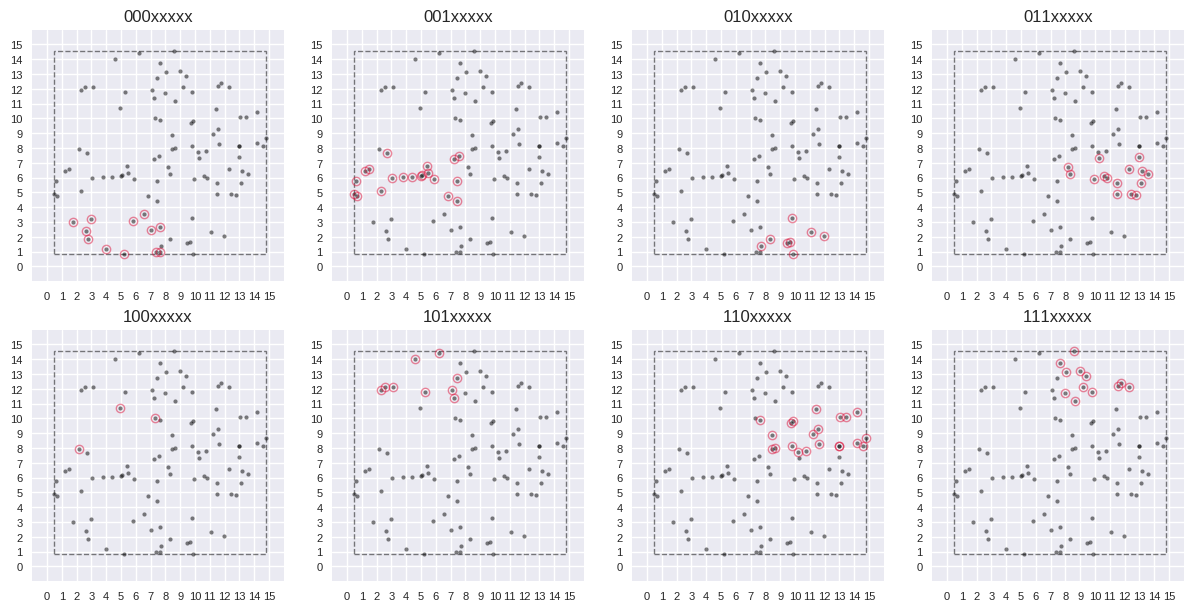

In [11]:
plot_regeions(points, codes, np.uint32(0b11100000), 4)

### 上位 4bits の領域

全体を 1/16 で分けた領域．

$$
\begin{array}{c c c c}
7 & 6 & 5 & 4 & 3 & 2 & 1 & 0\\
\hline
y_3 & x_3 & y_2 & x_2 & - & - & - & -\\
\end{array}
$$

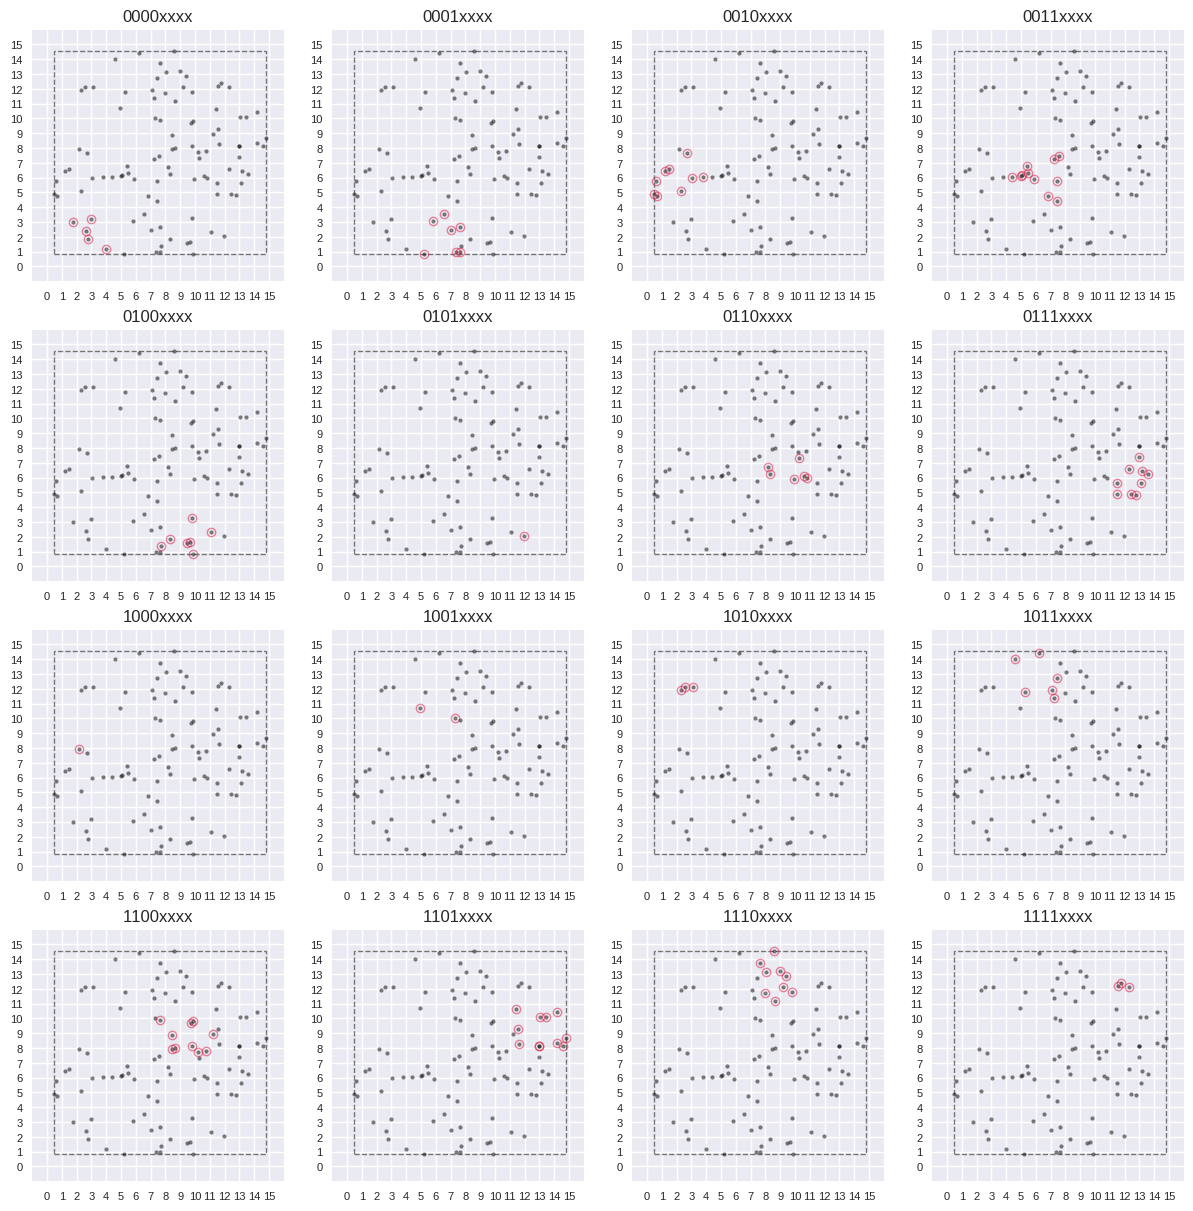

In [12]:
plot_regeions(points, codes, np.uint32(0b11110000), 4)

## References

- Wikipedia contributors. (2025, February 8). Z-order curve. Wikipedia. <https://en.wikipedia.org/w/index.php?title=Z-order_curve&oldid=1274694704>